## Crafting ABC Retail's Future with Python Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("transactions.csv")
df.info()
# we need to convert date into datetime format from object for analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  2000 non-null   int64  
 1   Product         2000 non-null   object 
 2   Category        2000 non-null   object 
 3   Quantity        2000 non-null   int64  
 4   Unit_Price      2000 non-null   float64
 5   Date            2000 non-null   object 
 6   Store           2000 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 109.5+ KB


In [3]:
df.head()

,Transaction_ID,Product,Category,Quantity,Unit_Price,Date,Store
0,1,Charger,Gadgets,4,956.903512,2022-06-01,Store_A
1,2,Laptop,Electronics,5,303.653831,2022-04-04,Store_B
2,3,Tablet,Gadgets,8,226.925798,2022-08-10,Store_A
3,4,Laptop,Electronics,4,975.494448,2022-04-22,Store_C
4,5,Mobile,Gadgets,8,656.776002,2022-03-05,Store_A


## Revenue Calculation

In [4]:
# 1. Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Transaction_ID  2000 non-null   int64         
 1   Product         2000 non-null   object        
 2   Category        2000 non-null   object        
 3   Quantity        2000 non-null   int64         
 4   Unit_Price      2000 non-null   float64       
 5   Date            2000 non-null   datetime64[ns]
 6   Store           2000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 109.5+ KB


In [5]:
# 2. Create Revenue column
df['Revenue'] = df['Quantity'] * df['Unit_Price']
df.head()

,Transaction_ID,Product,Category,Quantity,Unit_Price,Date,Store,Revenue
0,1,Charger,Gadgets,4,956.903512,2022-06-01,Store_A,3827.614047
1,2,Laptop,Electronics,5,303.653831,2022-04-04,Store_B,1518.269156
2,3,Tablet,Gadgets,8,226.925798,2022-08-10,Store_A,1815.406386
3,4,Laptop,Electronics,4,975.494448,2022-04-22,Store_C,3901.977794
4,5,Mobile,Gadgets,8,656.776002,2022-03-05,Store_A,5254.208013


## Revenue by Store

In [6]:
store_revenue = df.groupby('Store')['Revenue'].sum()
store_revenue

Store
Store_A    1.766111e+06
Store_B    1.563158e+06
Store_C    1.817864e+06
Name: Revenue, dtype: float64

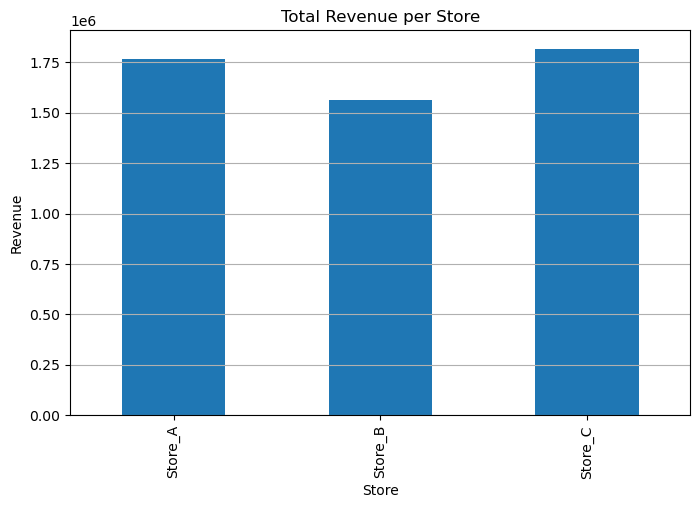

In [7]:
# Bar Plot (Vertical)
plt.figure(figsize=(8,5))
store_revenue.plot(kind='bar')

plt.title('Total Revenue per Store')
plt.ylabel('Revenue')
plt.xlabel('Store')

plt.grid(axis='y') 
plt.show()

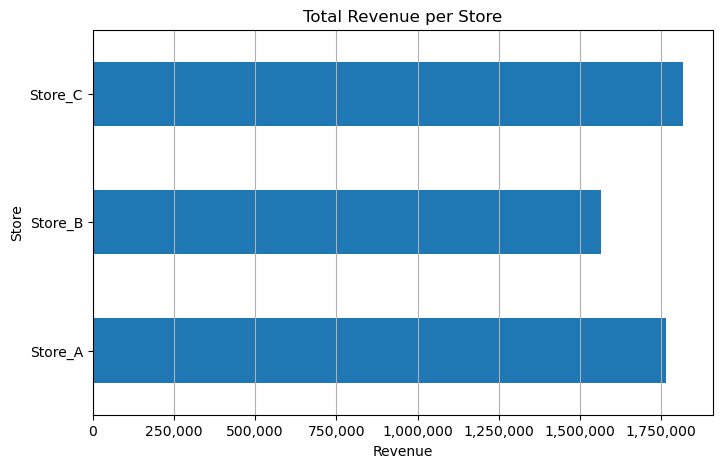

In [8]:
# Bar Plot (Horizontal)
import matplotlib.ticker as mticker

plt.figure(figsize=(8,5))
store_revenue.plot(kind='barh')

plt.title('Total Revenue per Store')
plt.xlabel('Revenue')
plt.ylabel('Store')

plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis='x') 
plt.show()

## Monthly Revenue Trend

In [9]:
# Extract the month from Date, then group by month to see revenue trends over time
df['Month'] = df['Date'].dt.month
df.head()

,Transaction_ID,Product,Category,Quantity,Unit_Price,Date,Store,Revenue,Month
0,1,Charger,Gadgets,4,956.903512,2022-06-01,Store_A,3827.614047,6
1,2,Laptop,Electronics,5,303.653831,2022-04-04,Store_B,1518.269156,4
2,3,Tablet,Gadgets,8,226.925798,2022-08-10,Store_A,1815.406386,8
3,4,Laptop,Electronics,4,975.494448,2022-04-22,Store_C,3901.977794,4
4,5,Mobile,Gadgets,8,656.776002,2022-03-05,Store_A,5254.208013,3


In [10]:
# Monthly Revenue
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue

Month
1     365986.810273
2     426452.461588
3     398036.137292
4     464157.221569
5     429056.766214
6     443771.123636
7     413733.554818
8     468731.025016
9     417630.696108
10    425184.599157
11    445097.859105
12    449295.068919
Name: Revenue, dtype: float64

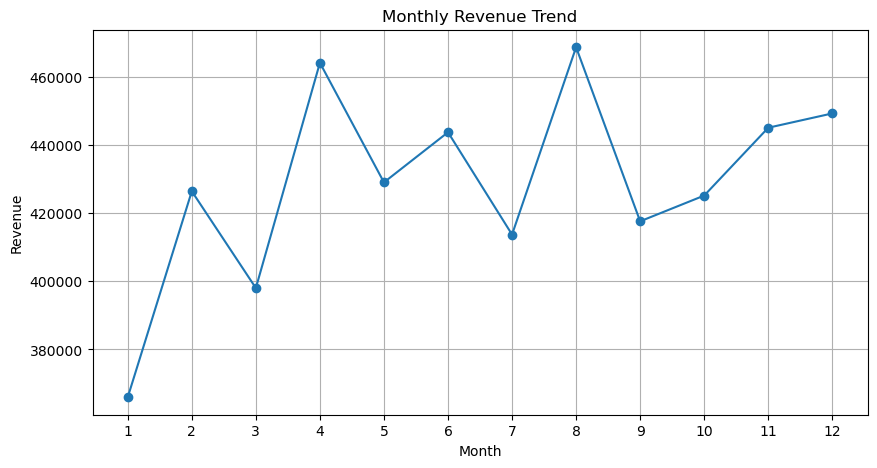

In [11]:
# Line Plot
plt.figure(figsize=(10,5))
monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(range(1,13)) 

plt.grid()
plt.show()

## TOP 5 Products by Sales Volume

In [12]:
product_sales = df.groupby('Product')['Quantity'].sum()
product_sales

Product
Charger       2062
Headphones    1924
Laptop        2129
Mobile        2211
Tablet        1874
Name: Quantity, dtype: int64

In [13]:
# Top 5
top5_products = product_sales.sort_values(ascending=False).head(5)
top5_products

Product
Mobile        2211
Laptop        2129
Charger       2062
Headphones    1924
Tablet        1874
Name: Quantity, dtype: int64

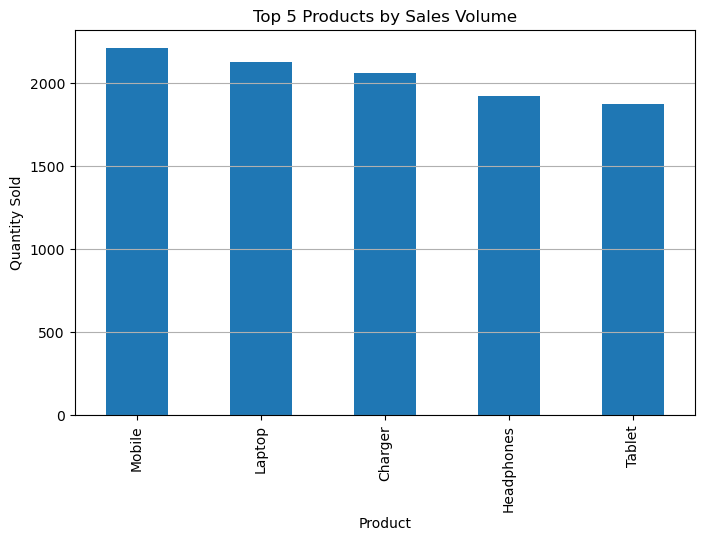

In [14]:
# Bar Plot
plt.figure(figsize=(8,5))
top5_products.plot(kind='bar')

plt.title('Top 5 Products by Sales Volume')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.grid(axis='y') 
plt.show()

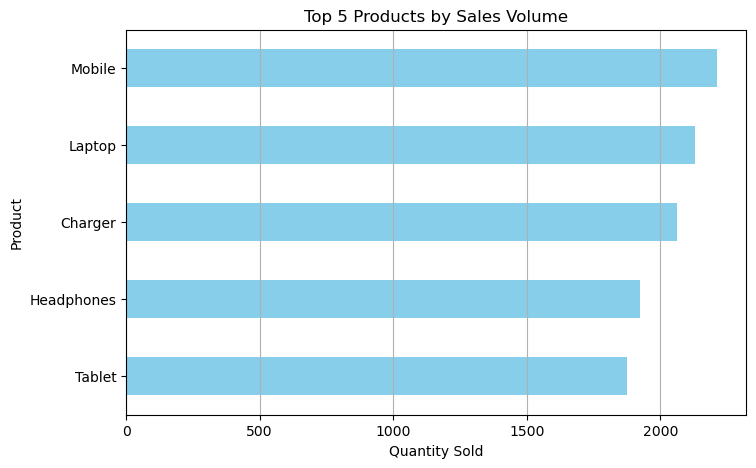

In [15]:
top5_products = product_sales.sort_values(ascending=False).head(5)

top5_products = top5_products[::-1]

plt.figure(figsize=(8,5))
top5_products.plot(kind='barh', color='skyblue')

plt.title('Top 5 Products by Sales Volume')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.grid(axis='x')
plt.show()

## Sales by Product Category (Plotly)

In [16]:
category_sales = df.groupby('Category')['Quantity'].sum().reset_index()
category_sales

,Category,Quantity
0,Accessories,3505
1,Electronics,3411
2,Gadgets,3284


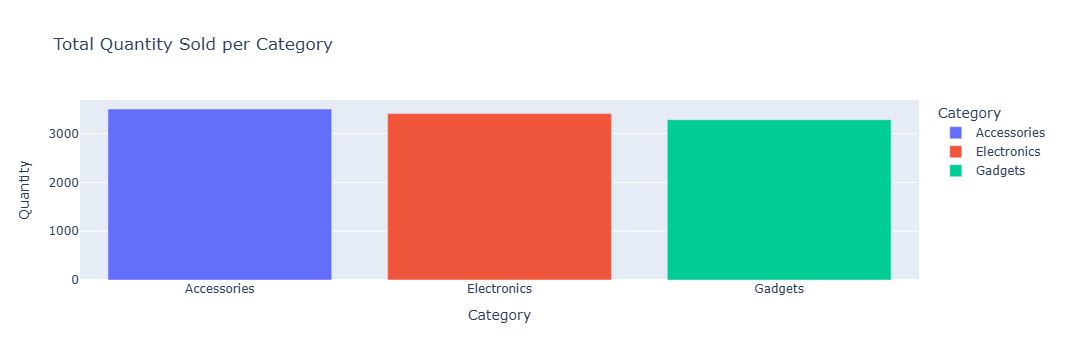

In [17]:
fig = px.bar(
    category_sales,
    x='Category',
    y='Quantity',
    title='Total Quantity Sold per Category',
    color='Category'
)

fig.show()

## Advanced Analysis

In [18]:
# Pivot Table: Monthly Revenue by Store

pivot_table = df.pivot_table(
    values='Revenue',
    index='Month',
    columns='Store',
    aggfunc='sum'
)
pivot_table = pivot_table.round(2)
pivot_table

Store,Store_A,Store_B,Store_C
Month,,,
1,155844.18,100283.58,109859.05
2,156625.91,113986.07,155840.47
3,80540.52,150940.81,166554.81
4,138393.32,151849.66,173914.24
5,160807.27,151298.04,116951.46
6,160766.09,105211.66,177793.37
7,139729.31,139308.34,134695.91
8,170930.82,146628.05,151172.16
9,138720.31,138825.61,140084.78


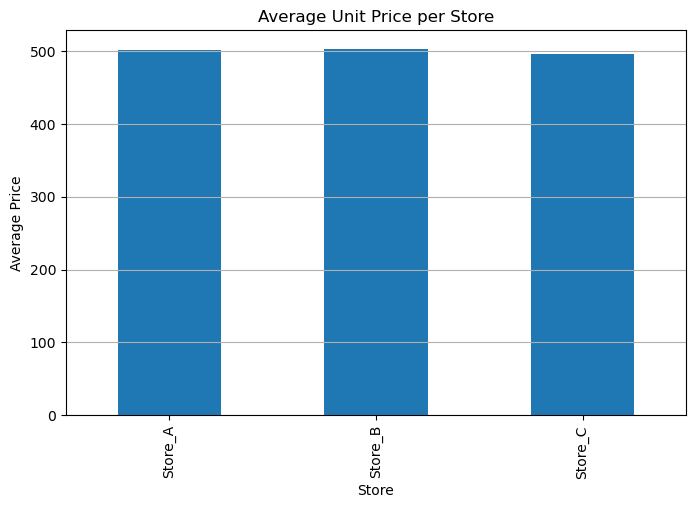

In [19]:
# Average Unit Price by Store
avg_price = df.groupby('Store')['Unit_Price'].mean()

plt.figure(figsize=(8,5))
avg_price.plot(kind='bar')

plt.title('Average Unit Price per Store')
plt.xlabel('Store')
plt.ylabel('Average Price')

plt.grid(axis='y') 
plt.show()

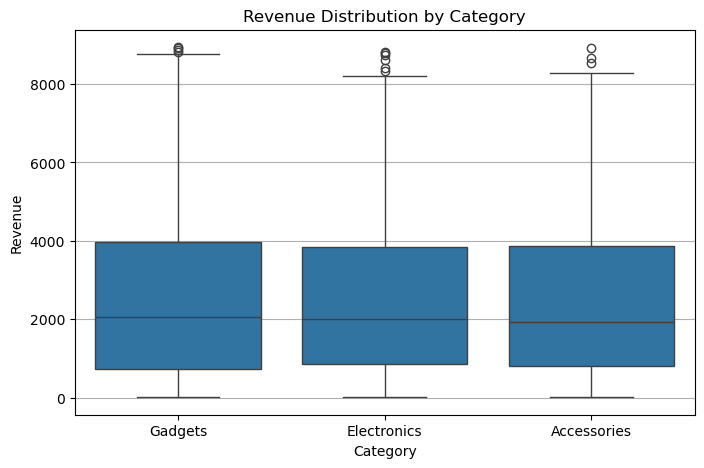

In [20]:
# Box Plot : Revenue Distribution by Category

plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Revenue', data=df)

plt.title('Revenue Distribution by Category')

plt.grid(axis='y')
plt.show()

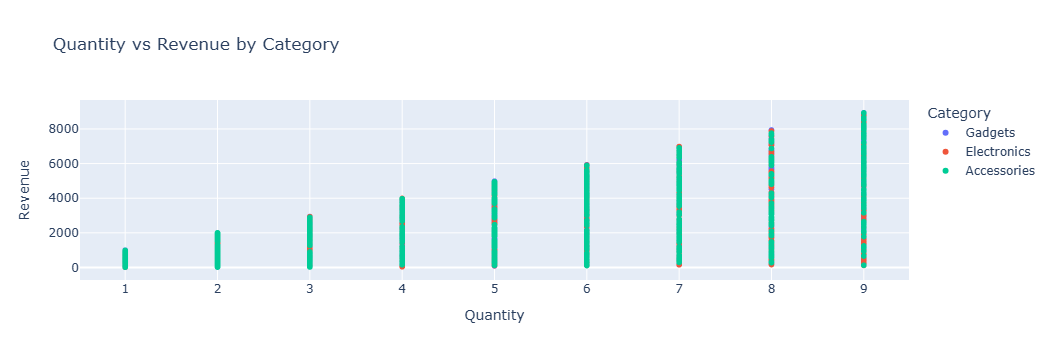

In [21]:
# Scatter Plot - Plotly

fig = px.scatter(
    df,
    x='Quantity',
    y='Revenue',
    color='Category',
    title='Quantity vs Revenue by Category'
)

fig.show()

## Final Verdict

The scatter plot shows a strong positive relationship between quantity and revenue across all categories. As the quantity sold increases, revenue also increases proportionally. Additionally, there is no significant difference between product categories, indicating that revenue growth is primarily driven by sales volume rather than category-specific pricing.